## Horizonte causalidad

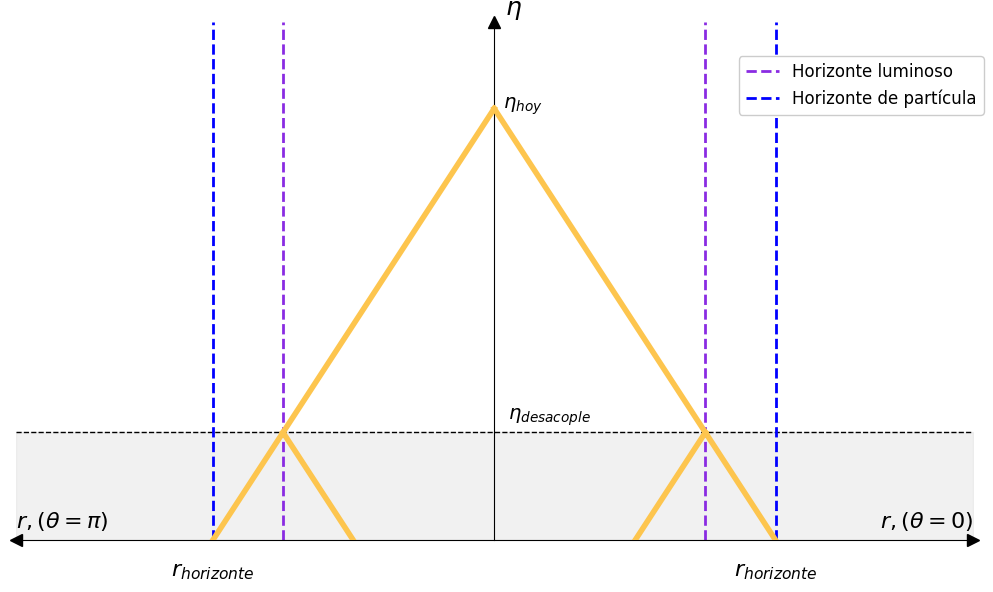

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de la figura
fig, ax = plt.subplots(figsize=(10, 6))

# Parámetros geométricos
eta_hoy = 10
eta_desacople = 2.5
r_interseccion = eta_hoy - eta_desacople
r_horizonte = r_interseccion + eta_desacople
ymax_limit = 12 # Límite superior del gráfico

# --- 1. DIBUJO DE LOS CONOS Y EL FONDO ---

# Área sombreada
ax.fill_between([-17, 17], 0, eta_desacople, color='lightgray', alpha=0.3, zorder=0)

# Cono de luz pasado (Principal - Amarillo)
ax.plot([0, r_interseccion], [eta_hoy, eta_desacople], color='#FDC54E', linewidth=4, zorder=5)
ax.plot([0, -r_interseccion], [eta_hoy, eta_desacople], color='#FDC54E', linewidth=4, zorder=5)

# Conos pequeños
# Derecho
ax.plot([r_interseccion, r_horizonte], [eta_desacople, 0], color='#FDC54E', linewidth=4, zorder=5)
ax.plot([r_interseccion, r_interseccion - eta_desacople], [eta_desacople, 0], color='#FDC54E', linewidth=4, zorder=5)
# Izquierdo
ax.plot([-r_interseccion, -r_horizonte], [eta_desacople, 0], color='#FDC54E', linewidth=4, zorder=5)
ax.plot([-r_interseccion, -(r_interseccion - eta_desacople)], [eta_desacople, 0], color='#FDC54E', linewidth=4, zorder=5)

# --- 2. LÍNEAS DE REFERENCIA Y LABELS (MODIFICADO) ---

# A) Línea horizontal negra en eta_desacople
ax.hlines(y=eta_desacople, xmin=-17, xmax=17, colors='black', linestyles='--', linewidth=1, zorder=1)
ax.text(0.5, eta_desacople + 0.3, r'$\eta_{desacople}$', fontsize=14, ha='left')

# B) Líneas verticales VIOLETAS (Horizonte Luminoso) - Con LABEL para leyenda
# CAMBIO: Color 'blueviolet' y agregado el parámetro label=
ax.vlines(x=[r_interseccion, -r_interseccion], ymin=0, ymax=ymax_limit,
          colors='blueviolet', linestyles='--', linewidth=2, zorder=2,
          label='Horizonte luminoso')

# C) Líneas verticales AZULES (Horizonte de partícula) - Con LABEL para leyenda
# CAMBIO: Agregado el parámetro label=
ax.vlines(x=[r_horizonte, -r_horizonte], ymin=0, ymax=ymax_limit,
          colors='blue', linestyles='--', linewidth=2, zorder=2,
          label='Horizonte de partícula')


# --- 3. EJES, ETIQUETAS Y LEYENDA ---

# Configurar ejes centrados
ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Flechas en los ejes
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False, markersize=8)
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=8)
ax.plot(0, 0, "<k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=8)

# Etiquetas de Ejes
ax.set_ylabel(r'$\eta$', fontsize=18, rotation=0, loc='top', labelpad=-20)
ax.text(17, 0.3, r'$r, (\theta=0)$', fontsize=16, ha='right')
ax.text(-17, 0.3, r'$r, (\theta=\pi)$', fontsize=16, ha='left')

# Etiquetas de puntos clave
ax.text(0.3, eta_hoy, r'$\eta_{hoy}$', fontsize=14)

# Etiquetas r_horizonte en el eje X
ax.text(r_horizonte, -0.5, r'$r_{horizonte}$', fontsize=16, fontweight= 'bold', ha='center', va='top')
ax.text(-r_horizonte, -0.5, r'$r_{horizonte}$', fontsize=16, fontweight= 'bold', ha='center', va='top')

# Limites y limpieza
ax.set_xlim(-17, 17)
ax.set_ylim(0, ymax_limit)
ax.set_xticks([])
ax.set_yticks([])

# AGREGAR LEYENDA (Genera los labels automáticamente basado en los vlines)
# ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.legend(loc='upper right', bbox_to_anchor=(1.02, 0.95), fontsize=12, framealpha=1, shadow=False)

plt.tight_layout()
plt.show()

## Baos - horizonte

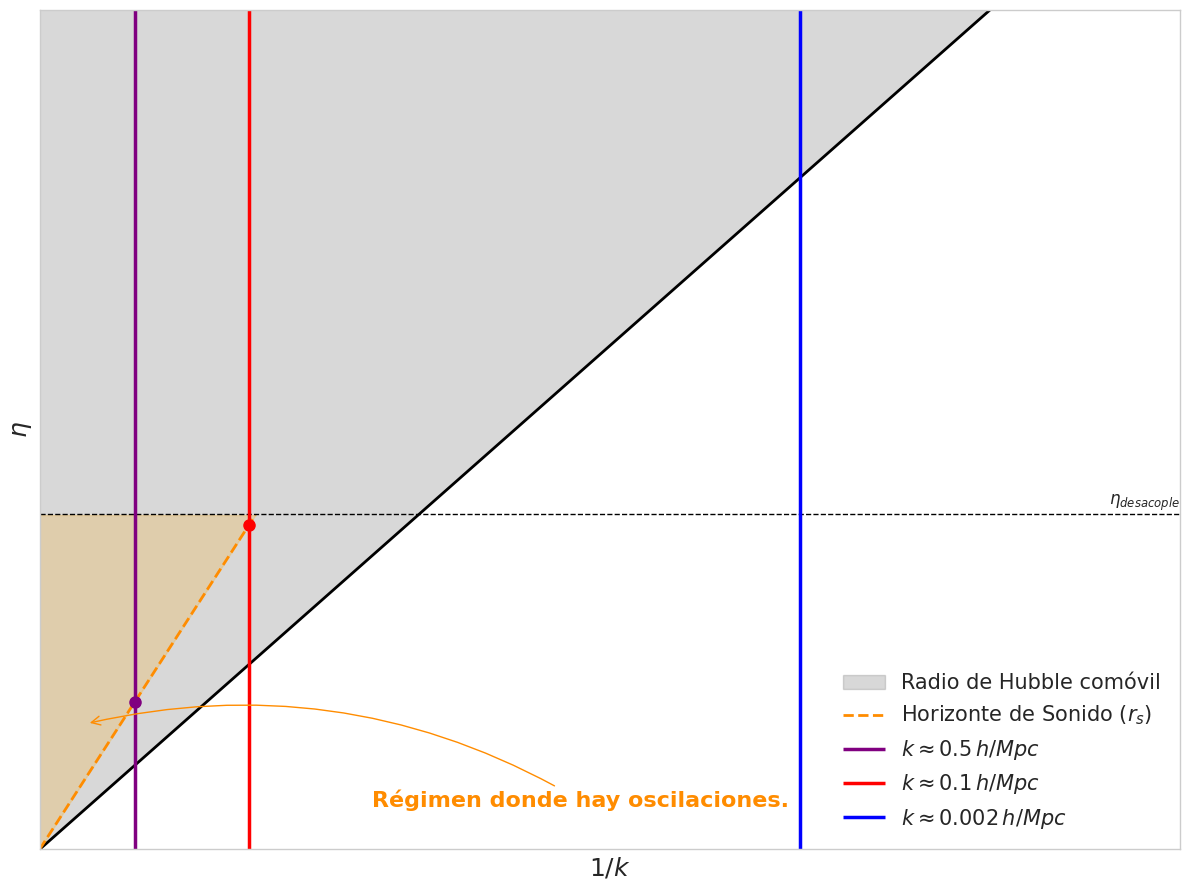

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de la figura
fig, ax = plt.subplots(figsize=(12, 9))

# --- PARÁMETROS FÍSICOS ---
# Unidades arbitrarias para visualización clara
eta_max = 14
eta_desacople = 4.0
c = 1.0          # Velocidad de la luz
c_s = 0.57       # Velocidad del sonido (aprox c/sqrt(3))

# Eje de tiempo conforme (eta)
eta = np.linspace(0, eta_max, 500)

# 1. Horizontes Comóviles (Evolución temporal)
# Radio de Hubble / Horizonte causal de luz (~ c * eta)
r_hubble = c * eta 
# Horizonte de Sonido (~ cs * eta) - Solo tiene sentido físico hasta el desacople
r_sonido = c_s * eta

# --- DIBUJO DE REGIONES ---

# Región Causal (Luz) - Gris claro
ax.fill_betweenx(eta, 0, r_hubble, color='gray', alpha=0.3, label='Radio de Hubble comóvil')
ax.plot(r_hubble, eta, color='black', linestyle='-', linewidth=2)

# Región de Sonido (Donde existen las BAO) - Naranja
# Solo dibujamos la región de sonido hasta el desacople
eta_sound = eta[eta <= eta_desacople]
r_sound_val = r_sonido[eta <= eta_desacople]
# Rellenamos hasta el eje Y=0
ax.fill_betweenx(eta_sound, 0, r_sound_val, color='orange', alpha=0.2)
ax.plot(r_sound_val, eta_sound, color='darkorange', linestyle='--', linewidth=2, label='Horizonte de Sonido ($r_s$)')

# Línea de Desacople
ax.hlines(eta_desacople, 0, 15, colors='black', linestyles='--', linewidth=1)
ax.text(12, eta_desacople + 0.01, r'$\eta_{desacople}$', fontsize=12, va='bottom', ha='right')

# --- MODOS K (ESCALAS COMÓVILES LAMBDA) ---
# Recordar: k grande = lambda chico (izquierda) | k chico = lambda grande (derecha)

# 1. MODO VIOLETA (k=0.601, Alto) -> Escala MUY PEQUEÑA
# Entra al horizonte de sonido muy temprano -> Oscila muchas veces
lambda_violeta = 1.0 
ax.vlines(lambda_violeta, 0, eta_max, colors='purple', linestyles='-', linewidth=2.5, label=r'$k \approx 0.5\, h/Mpc$')
# Punto de entrada al sonido
ax.plot(lambda_violeta, lambda_violeta/c_s, 'o', color='purple', markersize=8, zorder=10)

# 2. MODO ROJO (k=0.100, Medio) -> Escala MEDIA
# Entra al horizonte de sonido justo antes del desacople -> Oscila pocas veces
lambda_roja = 2.2
ax.vlines(lambda_roja, 0, eta_max, colors='red', linestyles='-', linewidth=2.5, label=r'$k \approx 0.1\, h/Mpc$')
# Punto de entrada al sonido
ax.plot(lambda_roja, lambda_roja/c_s, 'o', color='red', markersize=8, zorder=10)

# 3. MODO AZUL (k=0.002, Bajo) -> Escala MUY GRANDE
# Está fuera del horizonte de sonido en el desacople -> NO OSCILA (Supresión)
lambda_azul = 8.0
ax.vlines(lambda_azul, 0, eta_max, colors='blue', linestyles='-', linewidth=2.5, label=r'$k \approx 0.002\, h/Mpc$')
# Nota: Cruza la línea negra (luz) muy tarde, y nunca cruza la naranja antes del desacople.

# --- ANOTACIONES EXPLICATIVAS ---

# Flecha indicando región de oscilación
ax.annotate('Régimen donde hay oscilaciones.', 
            xy=(0.5, 1.5), xytext=(3.5, 0.5),
            arrowprops=dict(arrowstyle="->", color='darkorange', connectionstyle="arc3,rad=.2"),
            fontsize=16, color='darkorange', fontweight='bold')

# Texto para el modo azul
# ax.text(lambda_azul + 0.5, 2, 'Super-horizonte\n(Sin presión $\\to$ No oscila)', 
        # fontsize=10, color='blue', ha='left')

# --- FORMATO DE EJES ---

# Ejes centrados en (0,0) visualmente
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)

# Etiquetas
ax.set_ylabel(r'$\eta$', fontsize=18)
ax.set_xlabel(r'$1/k$', fontsize=18)

# Leyenda
ax.legend(loc='lower right', framealpha=1, fontsize=15)

# Quitar ticks numéricos para hacerlo esquemático
ax.set_xticks([])
ax.set_yticks([])

# Ajuste fino
plt.tight_layout()
plt.show()

## radio de Hubble y $k_{hor}$

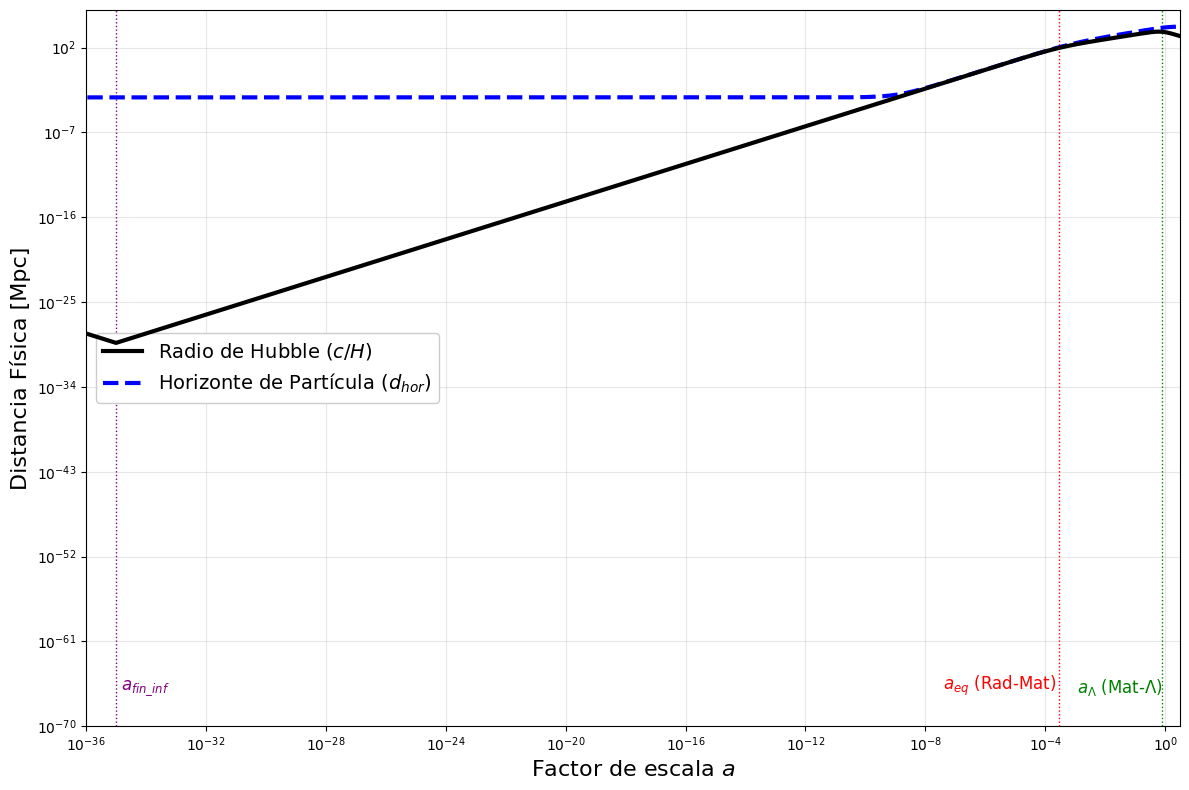

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate

# --- 1. CONFIGURACIÓN COSMOLÓGICA ---
H0 = 67.66          # km/s/Mpc
h = H0 / 100
Or0 = 4.17e-5 / h**2 # Radiación
Om0 = 0.3111         # Materia
Ol0 = 1.0 - Om0 - Or0 # Energía Oscura
c = 299792.458      # Velocidad luz km/s

# Parámetros de transición e Inflación
a_end_inf = 1e-35  # Punto donde termina inflación y empieza radiación
N_efolds = 60      # Cantidad de expansión durante inflación (e^60)

# Hitos estándar
a_eq = Or0 / Om0
a_lambda = (Om0 / Ol0)**(1/3)

# Rango de factor de escala (Grid muy fino para integración)
a = np.logspace(-55, 0.5, 10000)

# Máscaras para las regiones
mask_inf = a <= a_end_inf
mask_std = a > a_end_inf

# --- 2. CÁLCULO DE H(a) ---
H_a = np.zeros_like(a)

# H durante radiación justo después de inflación
H_at_transition = H0 * np.sqrt(Or0 * a_end_inf**(-4))

# Definimos H(a): Constante en inflación, estándar después
H_a[mask_inf] = H_at_transition # Asumimos continuidad en H
H_a[mask_std] = H0 * np.sqrt(Or0 * a[mask_std]**(-4) + Om0 * a[mask_std]**(-3) + Ol0)

# --- 3. CÁLCULO DE DISTANCIAS (ESTRATEGIA ROBÚSTA) ---

# A) Radio de Hubble (c/H)
R_H = c / H_a

# B) Horizonte de Partícula (d_hor) - Stitching analítico + numérico

# 1. Fase de Inflación (Analítico)
# En inflación, d_hor crece proporcional a 'a'.
# Al final de inflación, d_hor es e^N veces mayor que R_H.
inflation_factor = np.exp(N_efolds)
R_H_inf = R_H[mask_inf][0] # Valor constante de R_H en inflación
d_hor_at_end_inf = R_H_inf * inflation_factor

d_hor = np.zeros_like(a)
# Crecimiento lineal (pendiente 1 en log-log) durante inflación hasta alcanzar el valor final
d_hor[mask_inf] = d_hor_at_end_inf * (a[mask_inf] / a_end_inf)

# 2. Fase Estándar (Integración Numérica desde el final de inflación)
a_std = a[mask_std]
H_std = H_a[mask_std]
integrand_std = c / (a_std**2 * H_std)

# Horizonte comóvil acumulado DESDE el fin de inflación
delta_eta_std = integrate.cumulative_trapezoid(integrand_std, a_std, initial=0)

# Horizonte comóvil total = (acumulado en inflación) + (acumulado después)
eta_at_end_inf = d_hor_at_end_inf / a_end_inf
eta_total_std = eta_at_end_inf + delta_eta_std

# Distancia física d_hor = a * eta_total
d_hor[mask_std] = a_std * eta_total_std


# --- 4. GRAFICAR ---
fig, ax = plt.subplots(figsize=(12, 8))

# Curvas
ax.loglog(a, R_H/a, label=r'Radio de Hubble ($c/H$)', color='black', linewidth=3, zorder=10)
ax.loglog(a, d_hor/a, label=r'Horizonte de Partícula ($d_{hor}$)', color='blue', linestyle='--', linewidth=3, zorder=5)

# Líneas de transición
ax.axvline(a_end_inf, color='purple', linestyle=':', linewidth=1)
ax.axvline(a_eq, color='red', linestyle=':', linewidth=1)
ax.axvline(a_lambda, color='green', linestyle=':', linewidth=1)

# --- ETIQUETAS ---
# Ajustamos posiciones Y basadas en los nuevos límites del gráfico

# Etiquetas de Dominación (Arriba)
ymax_labels = 1e3 # Posición Y para textos superiores
# ax.text(1e-45, ymax_labels, 'INFLACIÓN\n($H \sim cte$)', color='purple', fontsize=12, ha='center', fontweight='bold')
# ax.text(1e-17, ymax_labels, 'RADIACIÓN\n($H \sim a^{-2}$)', color='red', fontsize=12, ha='center', fontweight='bold')
# ax.text(1e-2, ymax_labels, 'MATERIA\n($H \sim a^{-1.5}$)', color='black', fontsize=12, ha='center', fontweight='bold')
# ax.text(1.5, ymax_labels, 'ENERGÍA\nOSCURA', color='green', fontsize=12, ha='center', fontweight='bold')

# Etiquetas de Hitos (Abajo)
ymin_labels = 1e-67 # Posición Y cerca del borde inferior
ax.text(1e-34, ymin_labels, r'$a_{fin\_inf}$', color='purple', ha='center', va='bottom', fontsize=12)
ax.text(3e-06, ymin_labels, r'$a_{eq}$ (Rad-Mat)', color='red', ha='center', va='bottom', fontsize=12)
ax.text(3e-02, ymin_labels, r'$a_{\Lambda}$ (Mat-$\Lambda$)', color='green', ha='center', va='bottom', fontsize=12) # Un poco más arriba para que no se superponga

# Formato
ax.set_xlabel(r"Factor de escala $a$", fontsize=16)
ax.set_ylabel(r"Distancia Física [Mpc]", fontsize=16)
# ax.set_title(r"Evolución Completa del Horizonte Causal", fontsize=18)
ax.legend(fontsize=14, loc='center left', framealpha=1)
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.grid(True, which="minor", ls=":", alpha=0.1)

# Límites cruciales para ver todo el rango dinámico
ax.set_xlim(1e-36, 3)
ax.set_ylim(1e-70, 1e6)

plt.tight_layout()
plt.show()

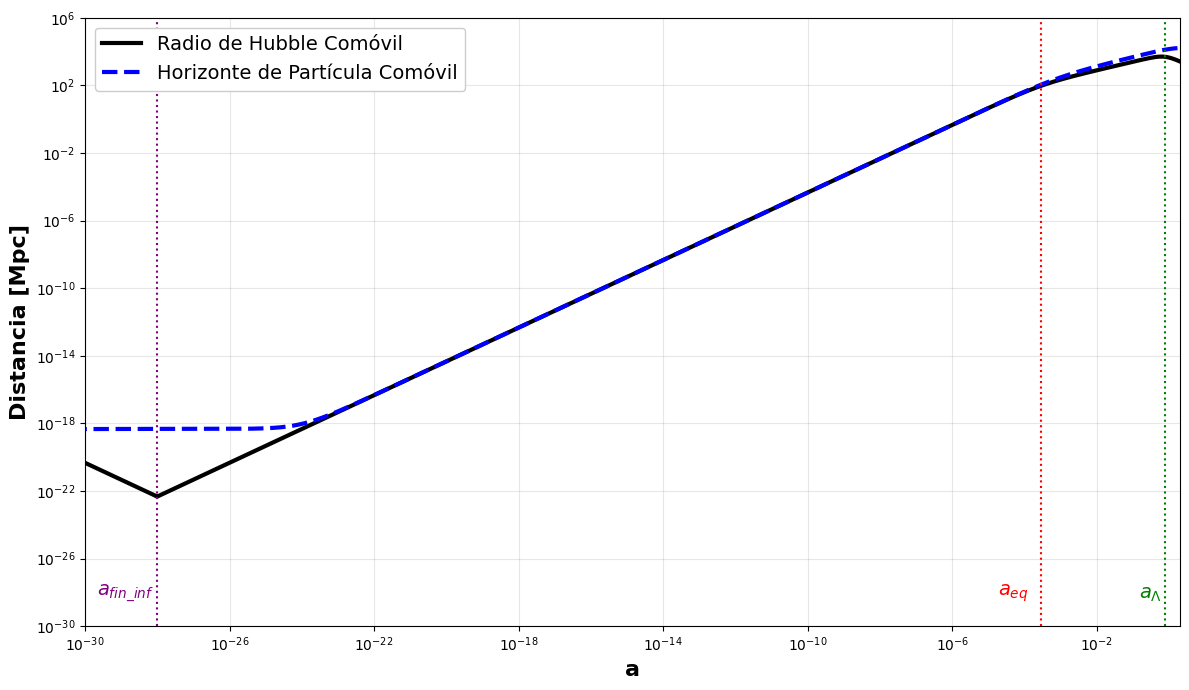

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate

# --- 1. CONFIGURACIÓN COSMOLÓGICA ---
H0 = 67.66          # km/s/Mpc
h = H0 / 100
Or0 = 4.17e-5 / h**2 # Radiación
Om0 = 0.3111         # Materia
Ol0 = 1.0 - Om0 - Or0 # Energía Oscura
c = 299792.458      # Velocidad luz km/s

# Parámetros de Transición e Inflación
a_end_inf = 1e-28  
N_efolds = 60      

# Hitos estándar
a_eq = Or0 / Om0
a_lambda = (Om0 / Ol0)**(1/3)

# Rango de cálculo
a = np.logspace(-32, 0.5, 5000)

mask_inf = a <= a_end_inf
mask_std = a > a_end_inf

# --- 2. CÁLCULO DE H(a) ---
H_a = np.zeros_like(a)
H_at_transition = H0 * np.sqrt(Or0 * a_end_inf**(-4))

H_a[mask_inf] = H_at_transition 
H_a[mask_std] = H0 * np.sqrt(Or0 * a[mask_std]**(-4) + Om0 * a[mask_std]**(-3) + Ol0)

# --- 3. CÁLCULO DE DISTANCIAS COMÓVILES ---

# A) Radio de Hubble Comóvil
R_H_comovil = c / (a * H_a)

# B) Horizonte de Partícula Comóvil
integrand_inf = c / (a[mask_inf]**2 * H_a[mask_inf])
eta_inf = integrate.cumulative_trapezoid(integrand_inf, a[mask_inf], initial=0)

eta_end_inf = eta_inf[-1]
integrand_std = c / (a[mask_std]**2 * H_a[mask_std])
eta_std = integrate.cumulative_trapezoid(integrand_std, a[mask_std], initial=0) + eta_end_inf

eta_total = np.zeros_like(a)
eta_total[mask_inf] = eta_inf
eta_total[mask_std] = eta_std

# --- 4. GRAFICAR ---
fig, ax = plt.subplots(figsize=(12, 7))

# Curvas
ax.loglog(a, R_H_comovil, label=r'Radio de Hubble Comóvil', color='black', linewidth=3)
ax.loglog(a, eta_total, label=r'Horizonte de Partícula Comóvil', color='blue', linestyle='--', linewidth=3)

# Líneas verticales de hitos
ax.axvline(a_end_inf, color='purple', linestyle=':', linewidth=1.5)
ax.axvline(a_eq, color='red', linestyle=':', linewidth=1.5)
ax.axvline(a_lambda, color='green', linestyle=':', linewidth=1.5)

# --- ETIQUETAS DE HITOS (Solo abajo) ---
# Ajuste fino de la posición vertical para que no toquen el eje X
y_text_bottom = 2e-29 

ax.text(8e-29, y_text_bottom, r'$a_{fin\_inf}$', color='purple', ha='right', va='bottom', fontsize=14)
ax.text(5e-05, y_text_bottom, r'$a_{eq}$', color='red', ha='center', va='bottom', fontsize=14)
ax.text(3e-1, y_text_bottom, r'$a_{\Lambda}$', color='green', ha='center', va='bottom', fontsize=14)

# --- FORMATO FINAL ---
ax.set_xlabel(r"a", fontweight='bold', fontsize=16)
ax.set_ylabel(r"Distancia [Mpc]", fontweight='bold', fontsize=16)

# Leyenda arriba a la izquierda (Zona vacía en este gráfico)
ax.legend(loc='upper left', fontsize=14, framealpha=1)

ax.grid(True, which="major", ls="-", alpha=0.3)
ax.grid(True, which="minor", ls=":", alpha=0.1)

# LÍMITES
ax.set_xlim(1e-30, 2)
ax.set_ylim(1e-30, 1e6)

plt.tight_layout()
plt.show()

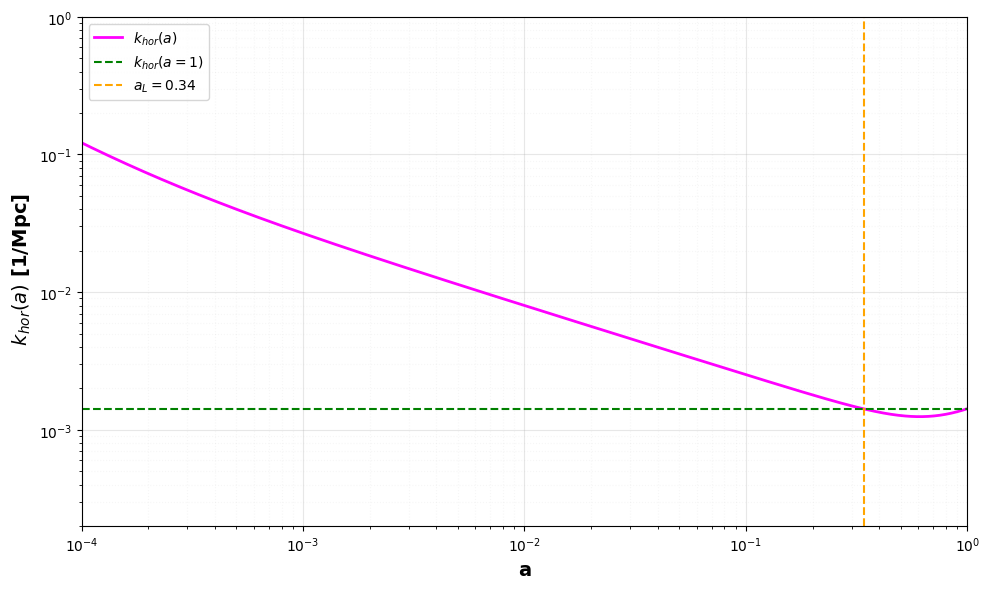

In [55]:
a_copy = a[a<=1]
H = 68*np.sqrt(0.0000417/a_copy**4 + 0.3111/a_copy**3 + 0.6889) # H(a) en km/s/Mpc
k_hor = 2*np.pi*a_copy*H/c
#plot k_hor vs radio Hubble comóvil
plt.figure(figsize=(10,6))
plt.loglog(a_copy, k_hor, label=r'$k_{hor}(a)$', color='magenta', linewidth=2)
# plt.loglog(a, R_H_comovil, label=r'$k = \frac{2\pi}{R_{H}}$', color='cyan', linestyle='--', linewidth=2)
plt.xlabel('a', fontsize=14, fontweight='bold')
plt.ylabel(r' $k_{hor}(a)$ [1/Mpc]', fontsize=14, fontweight='bold')
# plt.title('Evolución de las escalas comóviles k', fontsize=16)
plt.legend(fontsize=12)
plt.ylim(0.0002, 1)
plt.xlim(1e-4, 1)
#vline in a=0.003
#vline in a where k_hor=khor[-1] but index =! -1
index = np.where(np.abs(k_hor[:-1] - k_hor[-1]) == np.min(np.abs(k_hor[:-1] - k_hor[-1])))[0][0]
a_khor_last = a_copy[index]

#hline in khor[-1]
plt.axhline(y=k_hor[-1], color='green', linestyle='--', linewidth=1.5, label = r'$k_{hor}(a=1)$')
plt.axvline(x=a_khor_last, color='orange', linestyle='--', linewidth=1.5, label = f'$a_L={a_khor_last:.2f}$')
# plt.axvline(x=0.003, color='orange', linestyle='--', linewidth=1.5)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.grid(True, which="minor", ls=":", alpha=0.1)
plt.legend()
plt.tight_layout()
plt.show()

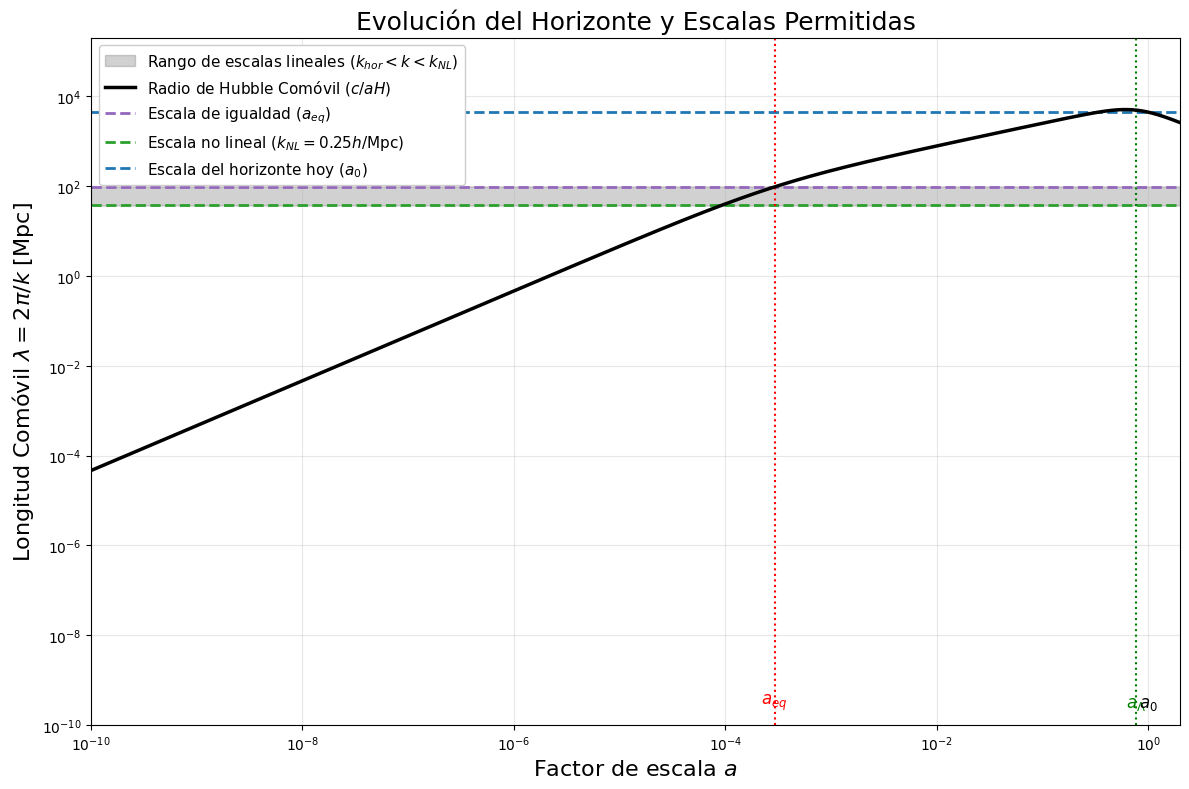

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURACIÓN COSMOLÓGICA ---
H0 = 67.66          # km/s/Mpc
h = H0 / 100
Or0 = 4.17e-5 / h**2 # Radiación
Om0 = 0.3111         # Materia
Ol0 = 1.0 - Om0 - Or0 # Energía Oscura
c = 299792.458      # Velocidad luz km/s

# Hitos estándar
a_eq = Or0 / Om0
a_lambda = (Om0 / Ol0)**(1/3)

# Rango de cálculo (Ajustado a tu pedido: 1e-10 a 2)
a = np.logspace(-10, 0.5, 5000)

# --- 2. CÁLCULO DE H(a) Y RADIO DE HUBBLE ---
# En este rango (1e-10 en adelante) ya no vemos inflación, usamos fórmula estándar
E_a = np.sqrt(Or0 * a**(-4) + Om0 * a**(-3) + Ol0)
H_a = H0 * E_a

# Radio de Hubble Comóvil (c / (a * H))
R_H_comovil = c / (a * H_a)

# --- 3. CÁLCULO DE ESCALAS (L = 2pi / k) ---

# A) Escala del horizonte en la igualdad (k_hor)
# Esta es la escala máxima linealmente interesante (el pico del espectro de potencias)
H_eq = H0 * np.sqrt(Or0 * a_eq**(-4) + Om0 * a_eq**(-3) + Ol0)
L_eq = c / (a_eq * H_eq) # L ~ 1/k_hor (aprox, usamos R_H en a_eq)

# B) Escala No Lineal (k_NL = 0.25 h/Mpc)
k_NL_h = 0.25 # h/Mpc
k_NL_fisico = k_NL_h * h # 1/Mpc (convertimos h)
L_NL = 2 * np.pi / k_NL_fisico # Longitud comóvil asociada

# C) Escala que sale hoy (Horizonte actual)
L_today = c / H0

# --- 4. GRAFICAR ---
fig, ax = plt.subplots(figsize=(12, 8))

# 1. Zona Gris Oscuro (Region permitida)
# Rellenamos entre la escala pequeña (L_NL) y la escala grande (L_eq) en todo el eje X
ax.fill_between(a, L_NL, L_eq, color='dimgray', alpha=0.3, zorder=0,
                label=r'Rango de escalas lineales ($k_{hor} < k < k_{NL}$)')

# 2. Curva Principal: Radio de Hubble Comóvil
ax.loglog(a, R_H_comovil, label=r'Radio de Hubble Comóvil $(c/aH)$', color='black', linewidth=2.5, zorder=10)

# 3. Líneas Horizontales
# Escala k_hor (Igualdad)
ax.axhline(L_eq, color='tab:purple', linestyle='--', linewidth=2,
           label=r'Escala de igualdad ($a_{eq}$)')

# Escala k_NL (No lineal)
ax.axhline(L_NL, color='tab:green', linestyle='--', linewidth=2,
           label=r'Escala no lineal ($k_{NL}=0.25 h$/Mpc)')

# Escala del Horizonte Hoy
ax.axhline(L_today, color='tab:blue', linestyle='--', linewidth=2,
           label=r'Escala del horizonte hoy ($a_0$)')

# --- 5. LÍNEAS VERTICALES DE HITOS ---
ax.axvline(a_eq, color='red', linestyle=':', linewidth=1.5)
ax.axvline(a_lambda, color='green', linestyle=':', linewidth=1.5)

# --- 6. ETIQUETAS Y TEXTOS ---
# Etiquetas de hitos (Abajo)
y_text_bottom = 2e-10 # Un poco por encima del límite inferior
ax.text(a_eq, y_text_bottom, r'$a_{eq}$', color='red', ha='center', va='bottom', fontsize=12)
ax.text(a_lambda, y_text_bottom, r'$a_{\Lambda}$', color='green', ha='center', va='bottom', fontsize=12)
ax.text(1.0, y_text_bottom, r'$a_0$', color='black', ha='center', va='bottom', fontsize=12)

# Formato Final
ax.set_xlabel(r"Factor de escala $a$", fontsize=16)
ax.set_ylabel(r"Longitud Comóvil $\lambda = 2\pi/k$ [Mpc]", fontsize=16)
ax.set_title(r"Evolución del Horizonte y Escalas Permitidas", fontsize=18)

# Leyenda
ax.legend(loc='upper left', fontsize=11, framealpha=1)

ax.grid(True, which="major", ls="-", alpha=0.3)
ax.grid(True, which="minor", ls=":", alpha=0.1)

# --- LÍMITES SOLICITADOS ---
ax.set_xlim(1e-10, 2)
ax.set_ylim(1e-10, 2e5)

plt.tight_layout()
plt.show()

## $G_{eff}$

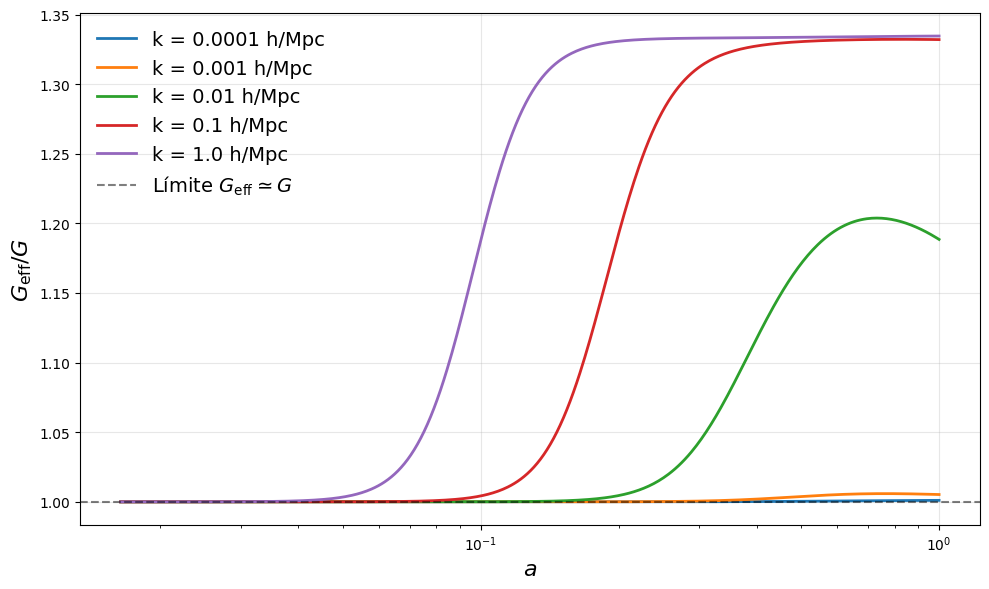

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/pedrorozin/scripts/python')
from delta_solver_mg_pedro import DeltaSolver

# 1. Definimos 6 modos k clave (escalas grandes a chicas, en h/Mpc)
# Podés ajustar estos valores según las escalas de los BAO o el horizonte que estés analizando.
k_values = [1e-4, 1e-3, 1e-2, 0.1, 1.0]

# 2. Armamos el vector de factor de escala y redshift
a_ini = 1 / (1 + 60)  # Acorde a tu DEFAULT_Z_INI_HS = 20
a_fin = 1.0
a_vec = np.logspace(np.log10(a_ini), np.log10(a_fin), 500)
z_vec = 1 / a_vec - 1
z_vec = np.clip(z_vec, 0, 60)  # Ensure values are within [0, 60]

# 3. Inicializamos tu DeltaSolver una única vez para resolver el background
# Usamos b=0.1 por defecto, pero podés cambiarlo para probar otros modelos
solver = DeltaSolver(b=0.01, z_ini_HS=60) 
_, _, r_num = solver.H_HS()

# 4. Configuramos la figura
plt.figure(figsize=(10, 6))

# 5. Iteramos sobre los modos k elegidos
for k_val in k_values:
    # Actualizamos el valor de k en el solver
    solver.k = k_val
    
    # Tu método Geff ya maneja arrays de z si le pasamos el interpolador r_num
    Geff_ratio = solver.Geff(z_vec, r_num)
    
    # Graficamos (usamos a_vec para el eje x, igual que en tu plot_delta)
    plt.plot(a_vec, Geff_ratio, label=f'k = {k_val} h/Mpc', lw=2)

# 6. Agregamos las asíntotas teóricas clásicas para f(R)
plt.axhline(1.0, color='k', linestyle='--', alpha=0.5, label='Límite $G_\mathrm{eff} \simeq G$')
# plt.axhline(4/3, color='gray', linestyle=':', alpha=0.8, label='Límite f(R) ($G_\mathrm{eff}/G = 4/3$)')

# 7. Detalles estéticos del gráfico
plt.xscale('log')
plt.xlabel('$a$', fontsize=16, fontweight='bold')
plt.ylabel('$G_\mathrm{eff} / G$', fontsize=16, fontweight='bold')
# plt.title('Transición de la gravedad efectiva para distintos modos (Modelo Hu-Sawicki)', fontsize=14)
plt.legend(frameon=False, loc='upper left', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [19]:
0.68*2*np.pi/0.0001

42725.66008882119

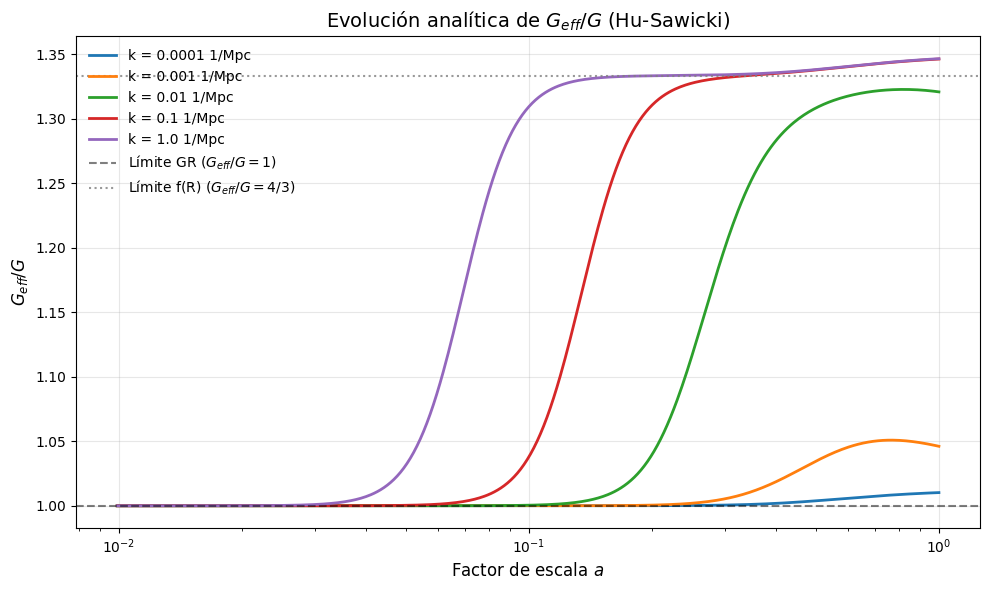

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c as c_ms

# Parámetros cosmológicos
Om_m_0 = 0.305
Om_L_0 = 1 - Om_m_0
h = 0.68
b = 0.1
c = c_ms / 1000  # km/s

# 1. Definimos modos k clave en 1/Mpc
k_values = [1e-4, 1e-3, 1e-2, 0.1, 1.0]

# 2. Vector del factor de escala
a_ini = 1 / (1 + 100)
a_fin = 1.0
a_vec = np.logspace(np.log10(a_ini), np.log10(a_fin), 500)

# 3. Cálculo analítico del background asumiendo Lambda-CDM
# R = 3 H_0^2 (Om_m * a^-3 + 4 * Om_L)
# Lambda = 3 H_0^2 * Om_L
# r = R / Lambda = (Om_m / Om_L) * a^-3 + 4
r_vec = (Om_m_0 / Om_L_0) * a_vec**-3 + 4

# Lambda en unidades de 1/Mpc^2
Lambda = 3 * (h * 100)**2 * Om_L_0 / c**2  

# 4. Derivadas del modelo Hu-Sawicki
# F = df/dR
F_vec = 1 - (2 / b) * (r_vec / b + 1)**-2

# dF/dR
dF_dR_vec = (4 / (Lambda * b**2)) * (r_vec / b + 1)**-3

# m = (1/F) * (dF/dR)
m_vec = (1 / F_vec) * dF_dR_vec

# 5. Configuración y ploteo
plt.figure(figsize=(10, 6))

for k in k_values:
    # Gravedad efectiva
    term_k = a_vec**2 / (m_vec * k**2)
    Geff_G = (1 / F_vec) * (1 + 1 / (3 + term_k))
    
    plt.plot(a_vec, Geff_G, label=f'k = {k} 1/Mpc', lw=2)

# Asintotas teóricas
plt.axhline(1.0, color='k', linestyle='--', alpha=0.5, label='Límite GR ($G_{eff}/G = 1$)')
plt.axhline(4/3, color='gray', linestyle=':', alpha=0.8, label='Límite f(R) ($G_{eff}/G = 4/3$)')

# Detalles del gráfico
plt.xscale('log')
plt.xlabel('Factor de escala $a$', fontsize=12)
plt.ylabel('$G_{eff} / G$', fontsize=12)
plt.title('Evolución analítica de $G_{eff}/G$ (Hu-Sawicki)', fontsize=14)
plt.legend(frameon=False, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## Funciones de activacion


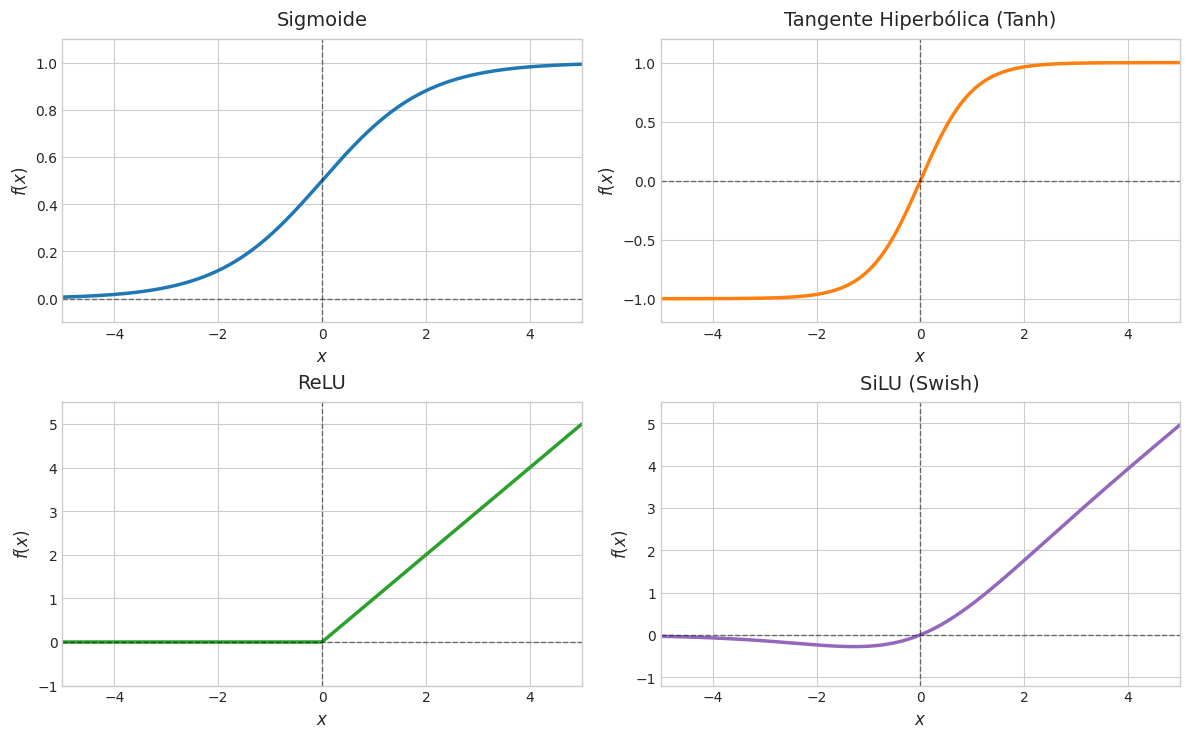

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo limpio y profesional (ideal para documentos formales)
plt.style.use('seaborn-v0_8-whitegrid')

# Definición de las funciones de activación
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def silu(x):
    return x * sigmoid(x)

# Rango de valores para el eje X
x = np.linspace(-5, 5, 400)

# Crear la figura y los subgráficos (2 filas, 2 columnas)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))


# Lista con la configuración de cada subplot: (eje, valores y, título, color, límites X, límites Y)
funcs = [
    (axs[0, 0], sigmoid(x), 'Sigmoide', '#1f77b4', (-5, 5), (-0.1, 1.1)),
    (axs[0, 1], tanh(x), 'Tangente Hiperbólica (Tanh)', '#ff7f0e', (-5, 5), (-1.2, 1.2)),
    (axs[1, 0], relu(x), 'ReLU', '#2ca02c', (-5, 5), (-1, 5.5)),
    (axs[1, 1], silu(x), 'SiLU (Swish)', '#9467bd', (-5, 5), (-1.2, 5.5))
]

# Bucle para plotear y darle estilo a cada gráfico
for ax, y, title, color, xlim, ylim in funcs:
    ax.plot(x, y, color=color, linewidth=2.5)
    ax.set_title(title, fontsize=14, pad=10)
    
    # Líneas punteadas en los ejes X=0 e Y=0 para referencia visual
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    
    # Límites y etiquetas
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_xlabel('$x$', fontsize=12)
    ax.set_ylabel('$f(x)$', fontsize=12)

# Ajustar el espaciado para que nada se superponga
plt.tight_layout()
plt.subplots_adjust(top=0.88)

# Guardar en alta calidad (300 DPI) para importar al documento de tesis
# plt.savefig('funciones_activacion_2x2.png', dpi=300, bbox_inches='tight')
plt.show()

## $H$ vs $H_{\Lambda CDM}$

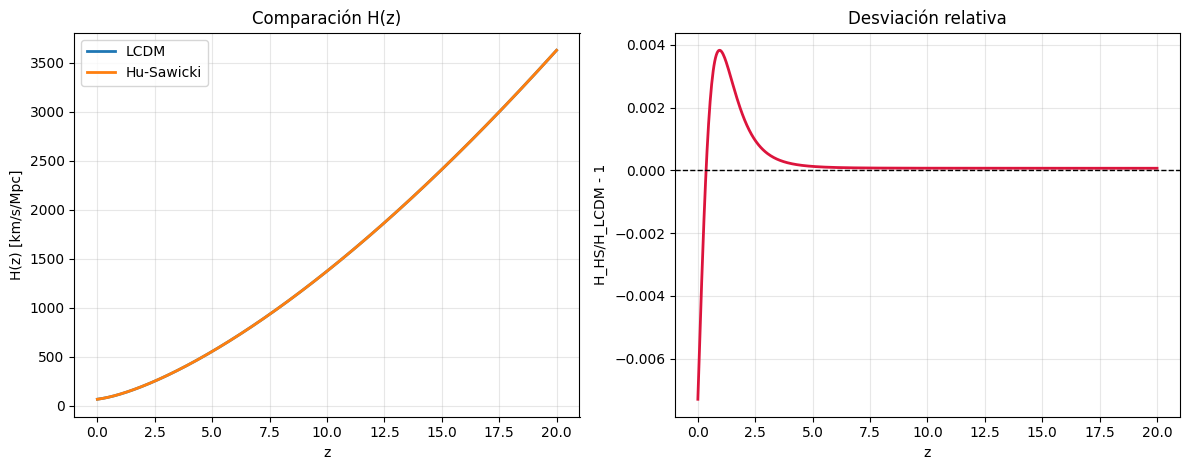

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/pedrorozin/scripts/python')
# Ajustá el import según tu estructura
# Si estás parado en /home/pedrorozin/scripts:
from delta_solver_mg_pedro import DeltaSolver

# 1) Crear solver con parámetros que quieras comparar
solver = DeltaSolver(
    Om_m_0=0.305,
    b=0.1,
    h=0.68,
    z_ini_HS=20,   # rango donde se integra HS internamente
    z_f=0
)

# 2) Obtener H(z)/H0 para ambos modelos
H_hs_interp, _, _ = solver.H_HS()   # devuelve interpolador de H_HS/H0
z = np.linspace(0.0, solver.z_ini_HS, 600)

H_lcdm = solver.H_LCDM(z)           # H_LCDM/H0
H_hs = H_hs_interp(z)               # H_HS/H0

# Si preferís unidades físicas (km/s/Mpc), multiplicá por H0:
H0 = 100.0 * solver.h
H_lcdm_phys = H_lcdm * H0
H_hs_phys = H_hs * H0

# 3) Plot con 2 paneles vertical (arriba H, abajo diferencia relativa)
fig, ax = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

# Panel superior: H(z)
ax[0].plot(z, H_lcdm_phys, lw=2.5, label="LCDM")
ax[0].plot(z, H_hs_phys, lw=2.5, label="Hu-Sawicki", linestyle='--')
ax[0].set_ylabel("H(z) [km/s/Mpc]", fontsize=12, fontweight='bold')
ax[0].set_title("Comparación H(z): LCDM vs Hu-Sawicki", fontsize=13, fontweight='bold')
ax[0].grid(alpha=0.3)
ax[0].legend(fontsize=11, loc='upper right')
ax[0].set_xticklabels([])  # Ocultamos las etiquetas del eje X del panel de arriba

# Panel inferior: diferencia relativa en porcentaje
rel_percent = ((H_hs_phys / H_lcdm_phys) - 1.0) * 100
ax[1].plot(z, rel_percent, lw=2.5, color="crimson")
ax[1].axhline(0.0, color="k", ls="--", lw=1)
ax[1].set_xlabel("z", fontsize=12, fontweight='bold')
ax[1].set_ylabel("Diferencia [%]", fontsize=12, fontweight='bold')
ax[1].grid(alpha=0.3)

# Ajustar espaciado vertical
plt.subplots_adjust(hspace=0.3)
plt.tight_layout()
plt.show()